# Exploratory Data Analysis

## 0. Import Packages

In [60]:
#basic
import numpy as np
import pandas as pd
import os

#plot
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap

#model training
from sklearn.model_selection import train_test_split, KFold
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error, median_absolute_error
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

#optimizer
from skopt import BayesSearchCV
from skopt.space import Real, Integer

#regressors
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

## 1. Import Dataset

In [25]:
#get user name
user_name = os.getlogin()
print(user_name)

root


In [26]:
#reading the local csv
if user_name == 'Yushu gong':
    df = pd.read_csv("C:\\Users\\Yushu gong\\Desktop\\Albert School\\ML-SL\\Final-Project\\company_esg_financial_dataset.csv")
else:
    df = pd.read_csv(r"/Users/vivianhung/Documents/git_project/Machine-Learning-Project/data/company_esg_financial_dataset.csv")

In [27]:
df.head(10)

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8
5,1,Company_1,Retail,Latin America,2020,567.5,6.0,384.1,2.3,55.7,65.1,28.5,73.5,42245.4,21122.7,84490.9
6,1,Company_1,Retail,Latin America,2021,604.2,5.2,479.3,6.5,55.6,66.8,25.5,74.6,44263.8,22131.9,88527.7
7,1,Company_1,Retail,Latin America,2022,593.2,4.2,248.4,-1.8,57.7,69.0,27.1,76.9,42536.3,21268.2,85072.6
8,1,Company_1,Retail,Latin America,2023,636.7,5.3,373.9,7.3,57.8,68.3,27.0,78.1,45956.3,22978.2,91912.6
9,1,Company_1,Retail,Latin America,2024,687.0,4.6,460.1,7.9,58.5,68.9,29.9,76.8,49289.1,24644.5,98578.1


In [15]:
df.columns

Index(['CompanyID', 'CompanyName', 'Industry', 'Region', 'Year', 'Revenue',
       'ProfitMargin', 'MarketCap', 'GrowthRate', 'ESG_Overall',
       'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'CarbonEmissions',
       'WaterUsage', 'EnergyConsumption'],
      dtype='object')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CompanyID          11000 non-null  int64  
 1   CompanyName        11000 non-null  object 
 2   Industry           11000 non-null  object 
 3   Region             11000 non-null  object 
 4   Year               11000 non-null  int64  
 5   Revenue            11000 non-null  float64
 6   ProfitMargin       11000 non-null  float64
 7   MarketCap          11000 non-null  float64
 8   GrowthRate         10000 non-null  float64
 9   ESG_Overall        11000 non-null  float64
 10  ESG_Environmental  11000 non-null  float64
 11  ESG_Social         11000 non-null  float64
 12  ESG_Governance     11000 non-null  float64
 13  CarbonEmissions    11000 non-null  float64
 14  WaterUsage         11000 non-null  float64
 15  EnergyConsumption  11000 non-null  float64
dtypes: float64(11), int64(

In [37]:
# the data set missing the one year of growthrate data
df_missing = df[df.isnull().any(axis=1)]
print(df_missing.shape)
df_missing.head(5)

(1000, 16)


,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
11,2,Company_2,Retail,Asia,2015,2934.8,-2.9,1803.1,NaN,59.9,61.1,48.6,69.8,226554.2,113277.1,453108.3
22,3,Company_3,Transportation,Latin America,2015,259.7,5.9,140.2,NaN,25.5,3.3,41.6,31.5,183314.5,30552.4,611048.2
33,4,Company_4,Technology,Africa,2015,5036.7,21.2,23192.4,NaN,54.2,97.6,46.2,18.9,130146.6,78087.9,260293.2
44,5,Company_5,Finance,Middle East,2015,2720.9,16.1,3884.5,NaN,43.5,71.9,19.1,39.4,37894.7,18947.3,94736.7


In [30]:
#checking the unique value and time deminsion
print('The dataset contains', df['Year'].nunique(), 'years data')
print('The numbers of company in this dataset is', df['CompanyID'].nunique())

The dataset contains 11 years data
The numbers of company in this dataset is 1000


In [35]:
#for plotting and training we take year 2016-2025 for the complete set of data be used
df_all = df.sort_values(by=['CompanyID', 'Year']).copy()
print("Before dropping the 2015's, we have the df shape as", df_all.shape)

df_final = df_all.dropna().reset_index(drop=True)
print("After dropping, we got the df shape as", df_final.shape)

Before dropping the 2015's, we have the df shape as (11000, 16)
After dropping, we got the df shape as (10000, 16)


## 2. EDA

### 2.1 ESG data by year/region view

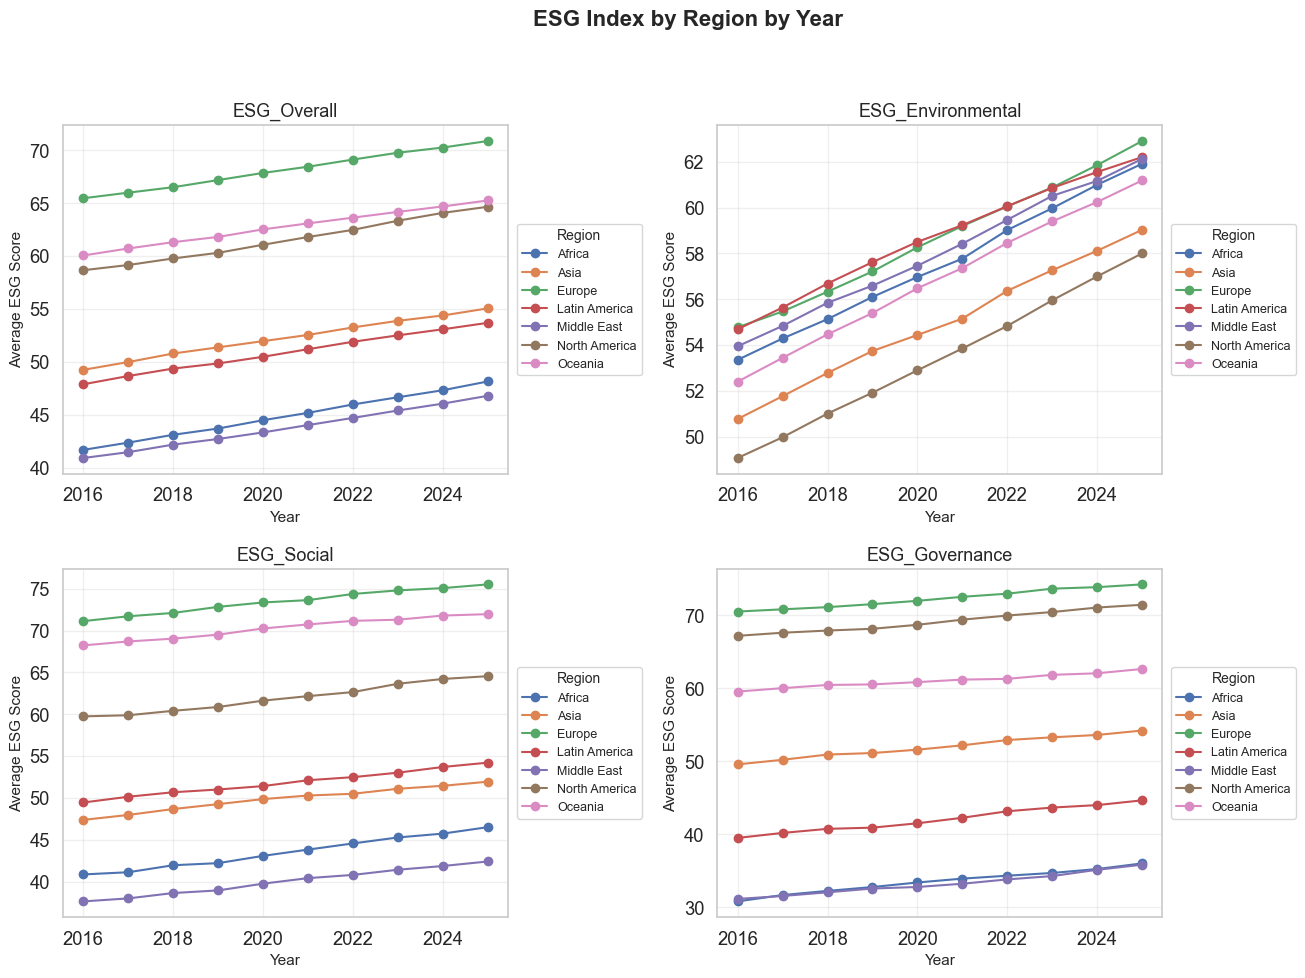

In [39]:
# ESG columns to plot
esg_columns = ['ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance']

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # flatten for easy iteration

for i, col in enumerate(esg_columns):
    ax = axes[i]
    df_avg = df_final.groupby(['Year', 'Region'])[col].mean().reset_index()

    # Plot each industry's trend
    for industry in df_avg['Region'].unique():
        data = df_avg[df_avg['Region'] == industry]
        ax.plot(data['Year'], data[col], marker='o', label=industry)

    # Titles and labels
    ax.set_title(f'{col}', fontsize=13)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Average ESG Score', fontsize=11)
    ax.grid(True, alpha=0.3)

    # Legend outside each subplot on the right
    ax.legend(
        title='Region',
        bbox_to_anchor=(1.02, 0.5),
        loc='center left',
        borderaxespad=0.,
        fontsize=9,
        title_fontsize=10
    )

# Add a single main title for the entire figure
fig.suptitle('ESG Index by Region by Year', fontsize=16, fontweight='bold')

# Adjust layout to leave space for the main title and legends
plt.tight_layout(rect=[0, 0, 0.95, 0.95])

plt.show()

### 2.2 ESG data by year/industry view

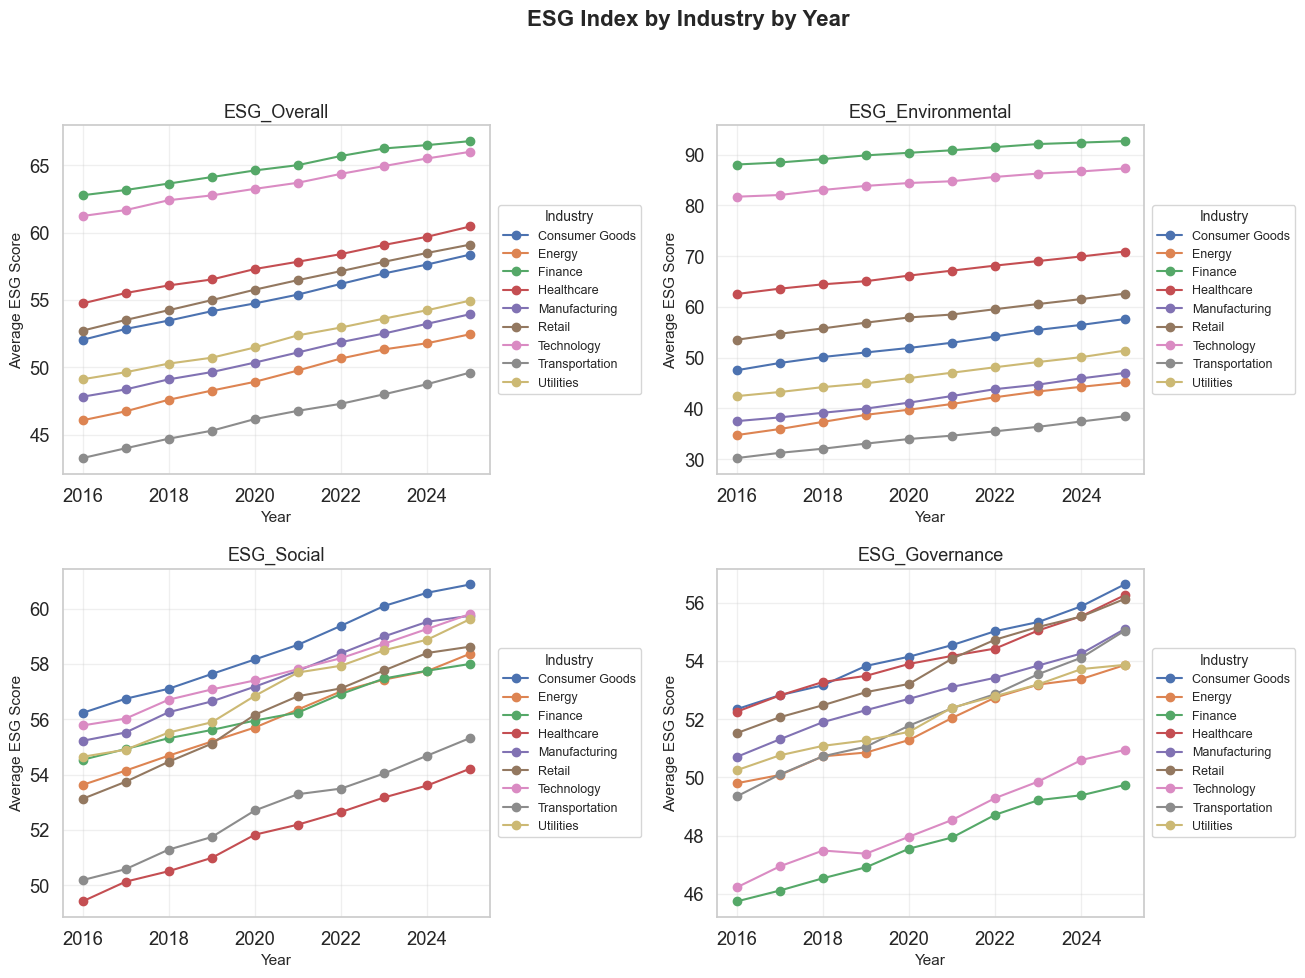

In [40]:
# ESG columns to plot
esg_columns = ['ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance']

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # flatten for easy iteration

for i, col in enumerate(esg_columns):
    ax = axes[i]
    df_avg = df_final.groupby(['Year', 'Industry'])[col].mean().reset_index()

    # Plot each industry's trend
    for industry in df_avg['Industry'].unique():
        data = df_avg[df_avg['Industry'] == industry]
        ax.plot(data['Year'], data[col], marker='o', label=industry)

    # Titles and labels
    ax.set_title(f'{col}', fontsize=13)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Average ESG Score', fontsize=11)
    ax.grid(True, alpha=0.3)

    # Legend outside each subplot on the right
    ax.legend(
        title='Industry',
        bbox_to_anchor=(1.02, 0.5),
        loc='center left',
        borderaxespad=0.,
        fontsize=9,
        title_fontsize=10
    )

# Add a single main title for the entire figure
fig.suptitle('ESG Index by Industry by Year', fontsize=16, fontweight='bold')

# Adjust layout to leave space for the main title and legends
plt.tight_layout(rect=[0, 0, 0.95, 0.95])

plt.show()

### 2.3 Does good ESG performance lead to (or coincide with) higher profitability?

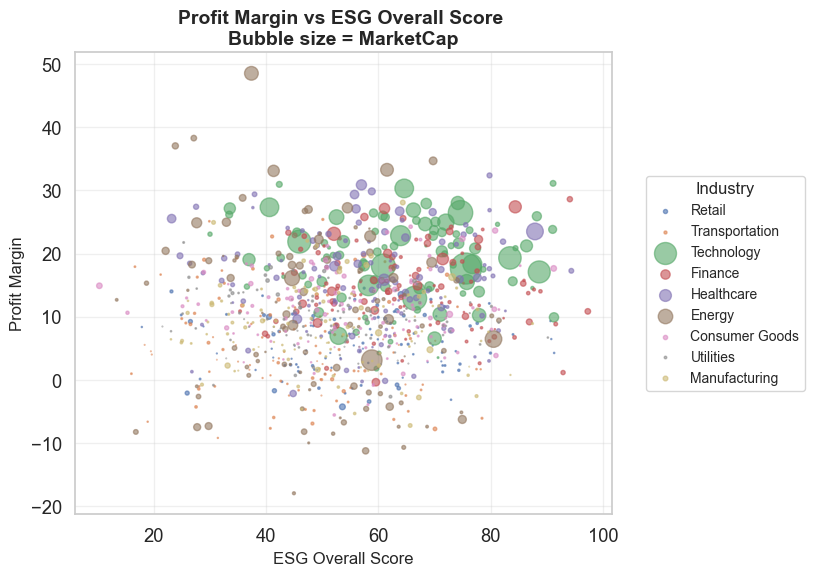

In [42]:
# prep data for plotting
cols_to_group = ['CompanyID', 'CompanyName', 'Industry', 'Region']

cols_to_avg = [
    'Revenue', 'ProfitMargin', 'MarketCap', 'GrowthRate', 'ESG_Overall',
    'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'CarbonEmissions',
    'WaterUsage', 'EnergyConsumption'
]

df_grp_by_company = (
    df_final
    .groupby(cols_to_group)[cols_to_avg]
    .mean()
    .reset_index()
)

# Normalize bubble size for better visualization
size_scale = 500  # Adjust this to change bubble sizes
sizes = df_grp_by_company['MarketCap'] / df_grp_by_company['MarketCap'].max() * size_scale

# Create bubble chart
plt.figure(figsize=(10, 6))
for industry in df_grp_by_company['Industry'].unique():
    data = df_grp_by_company[df_grp_by_company['Industry'] == industry]
    plt.scatter(
        data['ESG_Overall'],
        data['ProfitMargin'],
        s=data['MarketCap'] / df_grp_by_company['MarketCap'].max() * size_scale,  # bubble size
        alpha=0.6,
        label=industry
    )

# Labels and title
plt.xlabel('ESG Overall Score', fontsize=12)
plt.ylabel('Profit Margin', fontsize=12)
plt.title('Profit Margin vs ESG Overall Score \nBubble size = MarketCap', fontsize=14, fontweight='bold')

# Legend outside on the right
plt.legend(
    title='Industry',
    bbox_to_anchor=(1.05, 0.5),
    loc='center left',
    fontsize=10,
    title_fontsize=12
)

plt.grid(True, alpha=0.3)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

### 2.4 Distribution of Financial & ESG Metrics by Industry

/var/folders/_z/cd5g6gkj7h5ccbw0cjnj65y80000gn/T/ipykernel_50181/2385702566.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{10**t:,.0f}" if t > 0 else "" for t in ticks])
/var/folders/_z/cd5g6gkj7h5ccbw0cjnj65y80000gn/T/ipykernel_50181/2385702566.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{10**t:,.0f}" if t > 0 else "" for t in ticks])
/var/folders/_z/cd5g6gkj7h5ccbw0cjnj65y80000gn/T/ipykernel_50181/2385702566.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{10**t:,.0f}" if t > 0 else "" for t in ticks])
/var/folders/_z/cd5g6gkj7h5ccbw0cjnj65y80000gn/T/ipykernel_50181/2385702566.py:42: UserWarning: set_ticklabels() should only be used with a fixed numbe

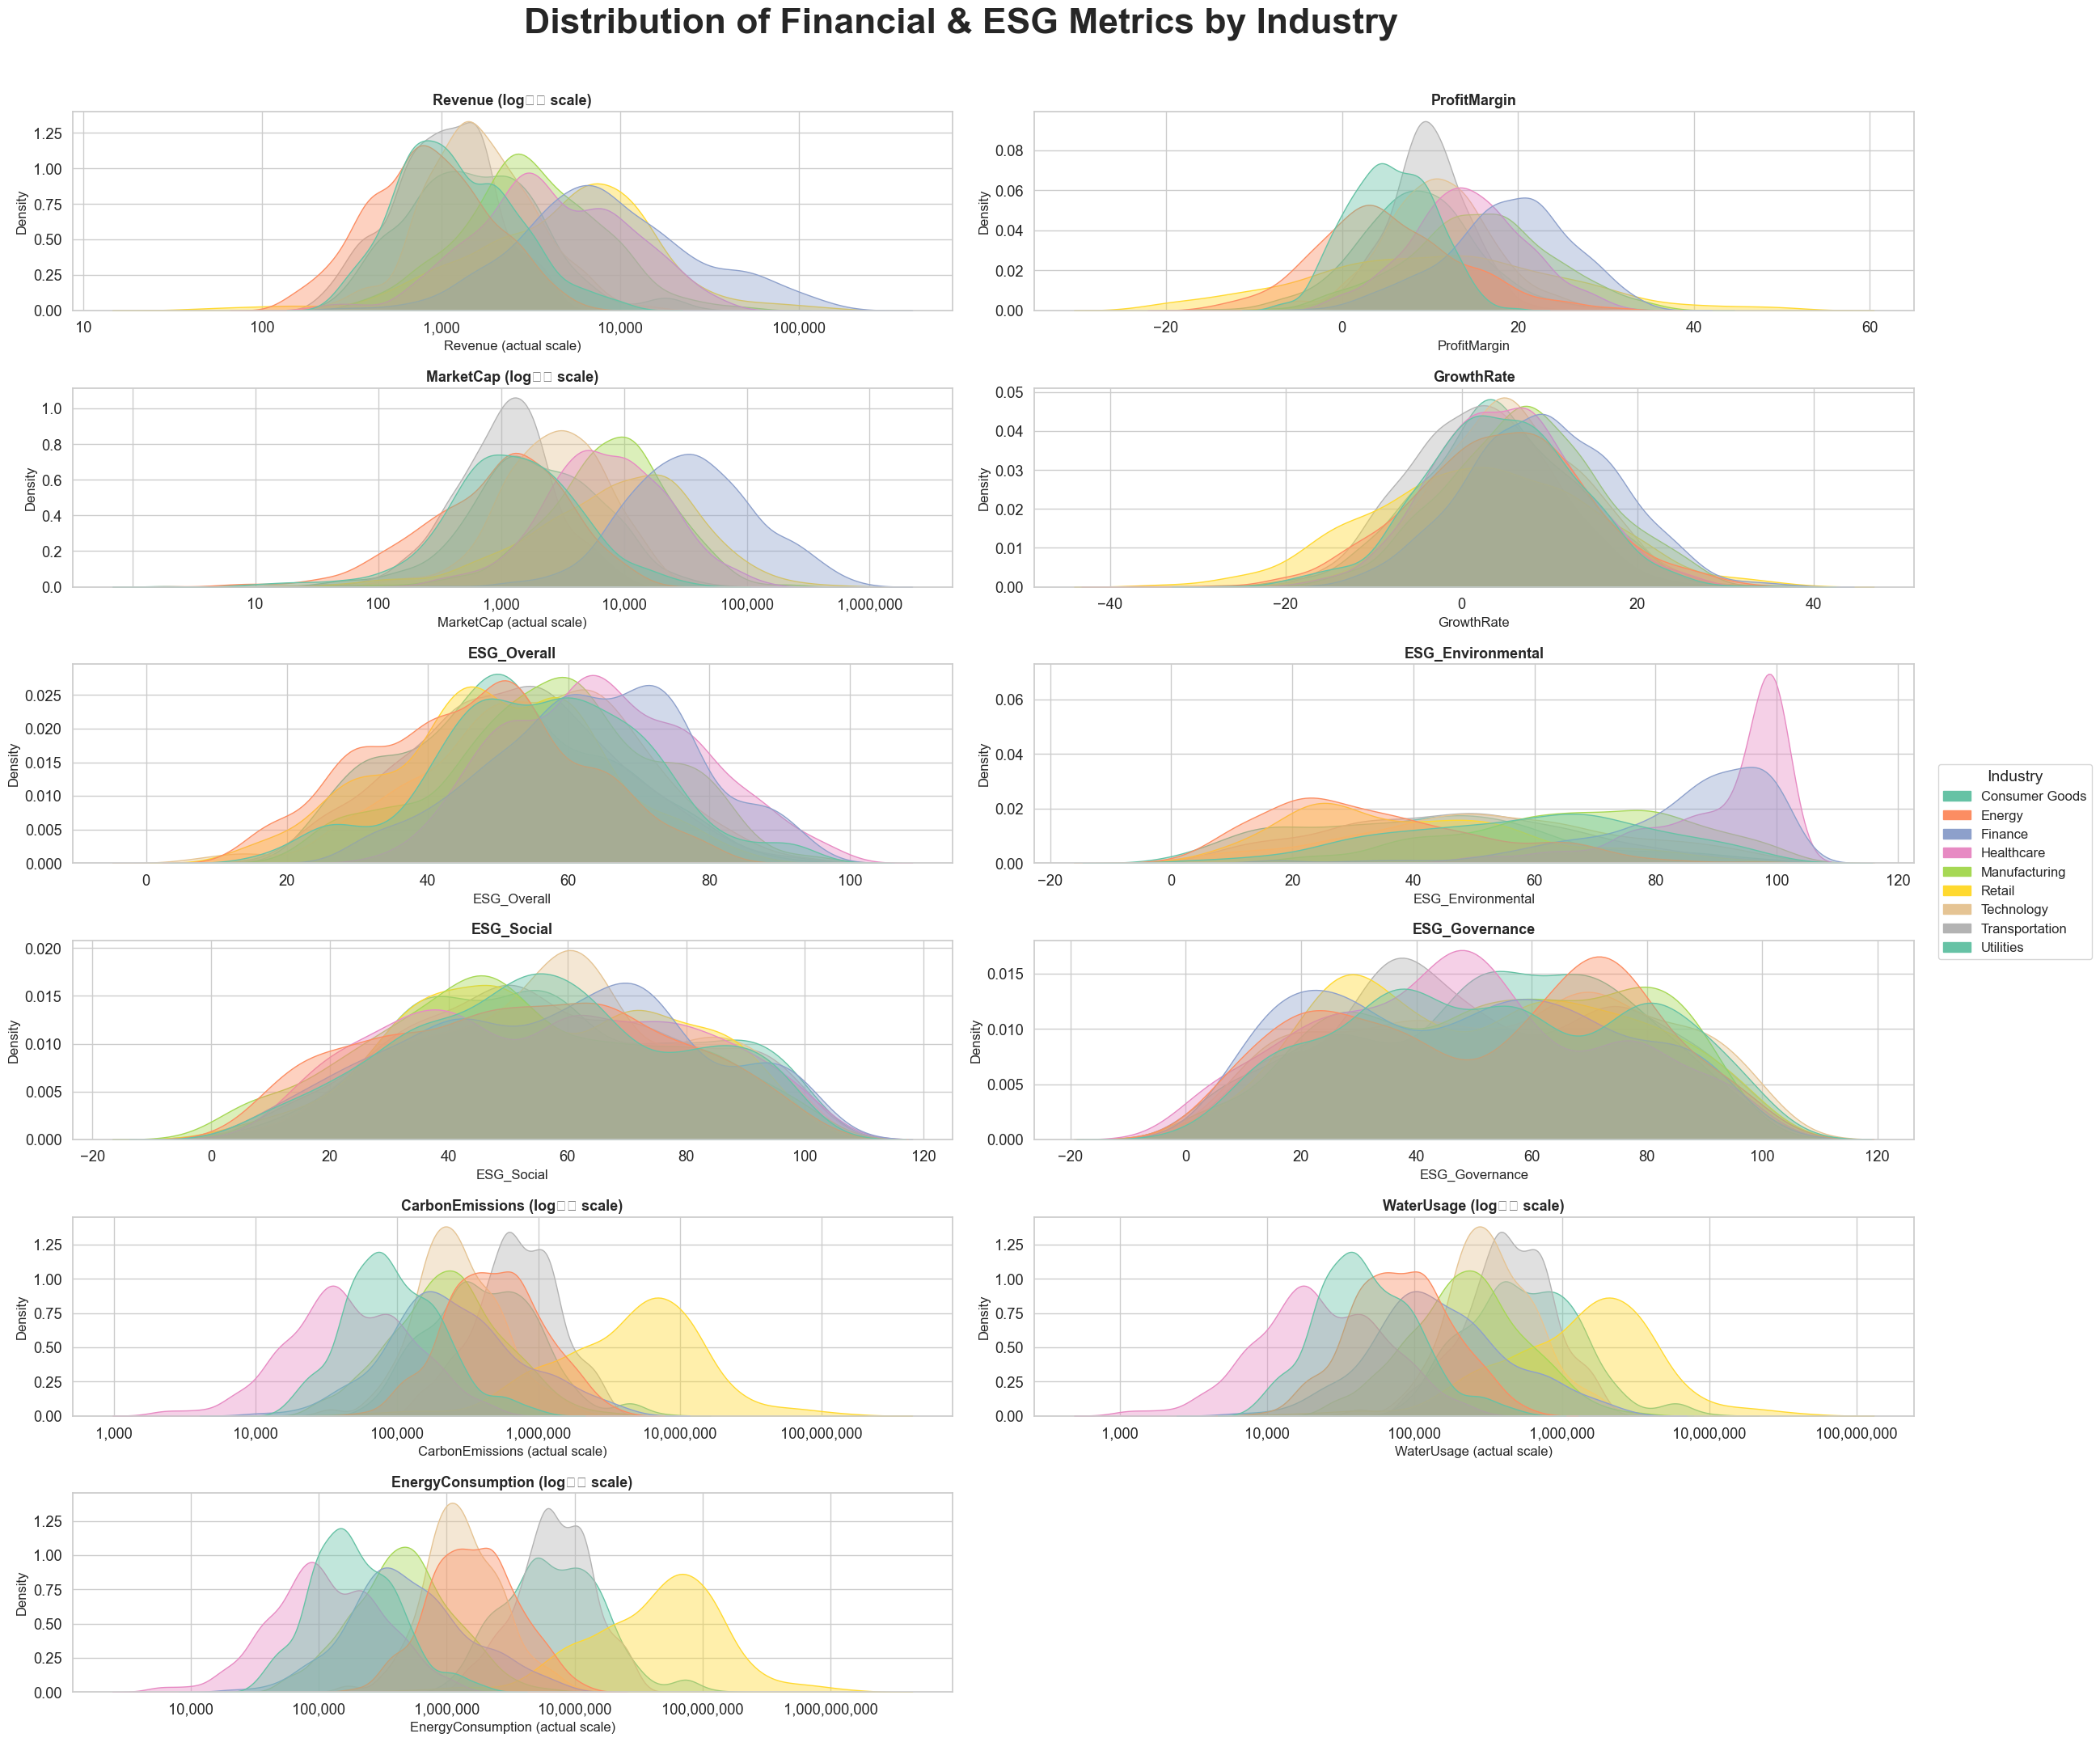

In [52]:
# Columns to visualize
cols_to_plot = [
    'Revenue', 'ProfitMargin', 'MarketCap', 'GrowthRate',
    'ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance',
    'CarbonEmissions', 'WaterUsage', 'EnergyConsumption'
]

# Columns that should use log-scale due to wide range
wide_range_cols = ['Revenue', 'MarketCap', 'CarbonEmissions', 'WaterUsage', 'EnergyConsumption']

# Plot setup
sns.set(style="whitegrid", font_scale=1.2)
palette = sns.color_palette("Set2", n_colors=df_final['Industry'].nunique())

n_cols = 2
n_rows = int(np.ceil(len(cols_to_plot) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 22))
axes = axes.flatten()

# Plot each feature
for i, col in enumerate(cols_to_plot):
    ax = axes[i]

    if col in wide_range_cols:
        df_plot = df_final.copy()
        df_plot[col] = np.log10(df_plot[col].replace(0, np.nan))

        sns.kdeplot(
            data=df_plot,
            x=col,
            hue="Industry",
            fill=True,
            common_norm=False,
            alpha=0.4,
            ax=ax,
            palette=palette,
            legend=False
        )

        ax.set_title(f"{col} (log₁₀ scale)", fontsize=13, fontweight="bold")
        ticks = ax.get_xticks()
        ax.set_xticklabels([f"{10**t:,.0f}" if t > 0 else "" for t in ticks])
        ax.set_xlabel(f"{col} (actual scale)", fontsize=12)

    else:
        sns.kdeplot(
            data=df_final,
            x=col,
            hue="Industry",
            fill=True,
            common_norm=False,
            alpha=0.4,
            ax=ax,
            palette=palette,
            legend=False
        )

        ax.set_title(col, fontsize=13, fontweight="bold")
        ax.set_xlabel(col, fontsize=12)

    ax.set_ylabel("Density", fontsize=12)

# Remove unused axes
for j in range(len(cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

# Legend
industries = sorted(df_final["Industry"].unique())
color_map = dict(zip(industries, palette))

patches = [
    mpatches.Patch(color=color_map[ind], label=ind)
    for ind in industries
]

fig.legend(
    handles=patches,
    title='Industry',
    bbox_to_anchor=(1, 0.5),
    loc='center left',
    fontsize=12,
    title_fontsize=14
)

# Layout & Title
plt.suptitle(
    "Distribution of Financial & ESG Metrics by Industry",
    fontsize=32,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### 2.5 Correlation Heatmap of Financial, ESG, and YoY Metrics

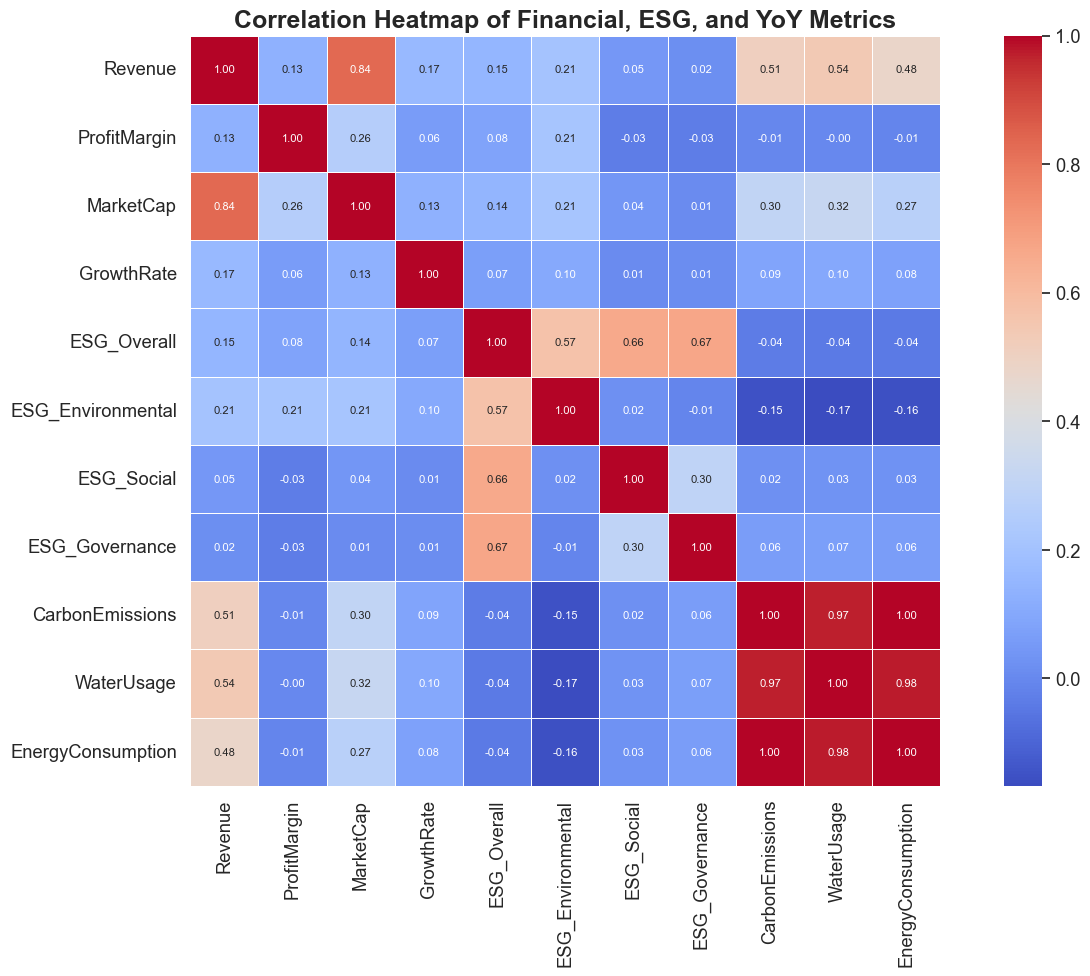

In [55]:
# Select only numeric columns that make sense for correlation
numeric_cols = [
    'Revenue', 'ProfitMargin', 'MarketCap', 'GrowthRate',
    'ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance',
    'CarbonEmissions', 'WaterUsage', 'EnergyConsumption'
]

# Compute correlation matrix
corr = df_final[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 8}
)

plt.title('Correlation Heatmap of Financial, ESG, and YoY Metrics', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()